# Bayesian Logistic Regression for Credit Card Default Prediction

**Dataset:** Default of Credit Card Clients (UCI Repository)  
**Source:** Taiwan credit card data, October 2005 (30,000 clients)  
**Task:** Binary classification — predict whether a client will default on next month's payment  
**Method:** Bayesian Logistic Regression with MCMC (NUTS sampler in PyMC)

---

## Project Roadmap

1. **Data loading & EDA** — understand variables, distributions, class imbalance
2. **Preprocessing** — clean coded categoricals, standardize numerics, train/test split
3. **Frequentist baselines** — Logistic Regression, XGBoost for benchmarking
4. **Bayesian Logistic Regression** — PyMC model with weakly informative priors
5. **Posterior analysis** — coefficient credible intervals, convergence diagnostics
6. **Calibration & comparison** — Brier score, Expected Calibration Error (ECE)
7. **Posterior predictive checks** — validate model fit
8. **Prior sensitivity analysis** — robustness across prior specifications
9. **Decision threshold analysis** — translate posteriors into a risk-tiered policy

## Dataset Reference (from Yeh & Lien, 2009)

This research employed a binary variable, **default payment (Yes = 1, No = 0)**, as the response variable. This study reviewed the literature and used the following **23 variables as explanatory variables**:

**Demographic and credit variables**

| Var | Description |
|---|---|
| **X1: LIMIT_BAL** | Amount of the given credit (NT dollar): it includes both the individual consumer credit and his/her family (supplementary) credit. |
| **X2: SEX** | Gender (1 = male; 2 = female). |
| **X3: EDUCATION** | Education (1 = graduate school; 2 = university; 3 = high school; 4 = others). |
| **X4: MARRIAGE** | Marital status (1 = married; 2 = single; 3 = others). |
| **X5: AGE** | Age (year). |

**X6 – X11: History of past payment**

We tracked the past monthly payment records (from April to September, 2005) as follows:

| Var | Month |
|---|---|
| **X6: PAY_0** | Repayment status in **September, 2005** |
| **X7: PAY_2** | Repayment status in **August, 2005** |
| **X8: PAY_3** | Repayment status in **July, 2005** |
| **X9: PAY_4** | Repayment status in **June, 2005** |
| **X10: PAY_5** | Repayment status in **May, 2005** |
| **X11: PAY_6** | Repayment status in **April, 2005** |

The measurement scale for the repayment status is:

- `-1` = pay duly
- `1` = payment delay for one month
- `2` = payment delay for two months
- `...`
- `8` = payment delay for eight months
- `9` = payment delay for nine months and above

**X12 – X17: Amount of bill statement (NT dollar)**

| Var | Month |
|---|---|
| **X12: BILL_AMT1** | Amount of bill statement in **September, 2005** |
| **X13: BILL_AMT2** | Amount of bill statement in **August, 2005** |
| **X14: BILL_AMT3** | Amount of bill statement in **July, 2005** |
| **X15: BILL_AMT4** | Amount of bill statement in **June, 2005** |
| **X16: BILL_AMT5** | Amount of bill statement in **May, 2005** |
| **X17: BILL_AMT6** | Amount of bill statement in **April, 2005** |

**X18 – X23: Amount of previous payment (NT dollar)**

| Var | Month |
|---|---|
| **X18: PAY_AMT1** | Amount paid in **September, 2005** |
| **X19: PAY_AMT2** | Amount paid in **August, 2005** |
| **X20: PAY_AMT3** | Amount paid in **July, 2005** |
| **X21: PAY_AMT4** | Amount paid in **June, 2005** |
| **X22: PAY_AMT5** | Amount paid in **May, 2005** |
| **X23: PAY_AMT6** | Amount paid in **April, 2005** |

---

**Source:** Yeh, I. C., & Lien, C. H. (2009). The comparisons of data mining techniques for the predictive accuracy of probability of default of credit card clients. *Expert Systems with Applications*, 36(2), 2473–2480. [https://doi.org/10.1016/j.eswa.2007.12.020](https://doi.org/10.1016/j.eswa.2007.12.020)

**Dataset:** UCI Machine Learning Repository — [https://archive.ics.uci.edu/dataset/350/default+of+credit+card+clients](https://archive.ics.uci.edu/dataset/350/default+of+credit+card+clients)

---

### Notes on undocumented codes (observed during EDA, not in the original paper)

The original codebook does not document a few values that appear in the data. We follow common community practice:

- **EDUCATION** contains values `0`, `5`, `6` not in the official `{1,2,3,4}` scheme → merged into category `4` (*others*).
- **MARRIAGE** contains value `0` not in the official `{1,2,3}` scheme → merged into category `3` (*others*).
- **PAY_X** contains values `-2` and `0` not in the official `{-1, 1, 2, ..., 9}` scheme. Common interpretations: `-2` = no consumption / no credit usage; `0` = use of revolving credit (balance carried but no delinquency). These are kept as-is in the model.


In [1]:
pip install xgboost xlrd

Note: you may need to restart the kernel to use updated packages.


In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import pymc as pm
import arviz as az

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    roc_auc_score, brier_score_loss, confusion_matrix,
    classification_report, roc_curve
)
from sklearn.calibration import calibration_curve

import xgboost as xgb



print('PyMC version:', pm.__version__)
print('ArviZ version:', az.__version__)

PyMC version: 5.28.4
ArviZ version: 0.23.4


## 1. Load data

Rename the PAY_0 to PAY_1, avoding misunderstanding of payment date

In [3]:
df = pd.read_excel('default_of_credit_ card_clients.xls', header=1)
df = df.rename(columns={'default payment next month': 'default', 'PAY_0': 'PAY_1'})
df = df.drop(columns=['ID'])

print('Shape:', df.shape)
print('Missing values:', df.isnull().sum().sum())
df.head()

Shape: (30000, 24)
Missing values: 0


,LIMIT_BAL,SEX,EDUCATION,MARRIAGE,AGE,PAY_1,PAY_2,PAY_3,PAY_4,PAY_5,...,BILL_AMT4,BILL_AMT5,BILL_AMT6,PAY_AMT1,PAY_AMT2,PAY_AMT3,PAY_AMT4,PAY_AMT5,PAY_AMT6,default
0,20000,2,2,1,24,2,2,-1,-1,-2,...,0,0,0,0,689,0,0,0,0,1
1,120000,2,2,2,26,-1,2,0,0,0,...,3272,3455,3261,0,1000,1000,1000,0,2000,1
2,90000,2,2,2,34,0,0,0,0,0,...,14331,14948,15549,1518,1500,1000,1000,1000,5000,0
3,50000,2,2,1,37,0,0,0,0,0,...,28314,28959,29547,2000,2019,1200,1100,1069,1000,0
4,50000,1,2,1,57,-1,0,-1,0,0,...,20940,19146,19131,2000,36681,10000,9000,689,679,0


## 2. EDA

### 2.1 Target distribution

default
0    23364
1     6636
Name: count, dtype: int64

Default rate: 0.2212


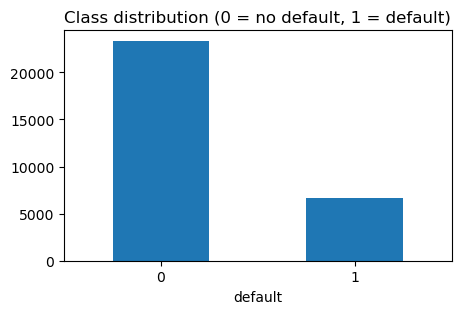

In [4]:
print(df['default'].value_counts())
print('\nDefault rate:', df['default'].mean().round(4))

plt.figure(figsize=(5, 3))
df['default'].value_counts().plot(kind='bar')
plt.title('Class distribution (0 = no default, 1 = default)')
plt.xticks(rotation=0)
plt.show()

### 2.2 Default rate by repayment status (PAY_1)

PAY_X variables encode repayment delay in months. According to the codebook:
- `-2, -1, 0` = paid in full or on time
- `1, 2, ..., 8` = delayed by that many months

This is expected to be the strongest predictor.

    PAY_1      mean  count
0      -2  0.132294   2759
1      -1  0.167781   5686
2       0  0.128113  14737
3       1  0.339479   3688
4       2  0.691414   2667
5       3  0.757764    322
6       4  0.684211     76
7       5  0.500000     26
8       6  0.545455     11
9       7  0.777778      9
10      8  0.578947     19


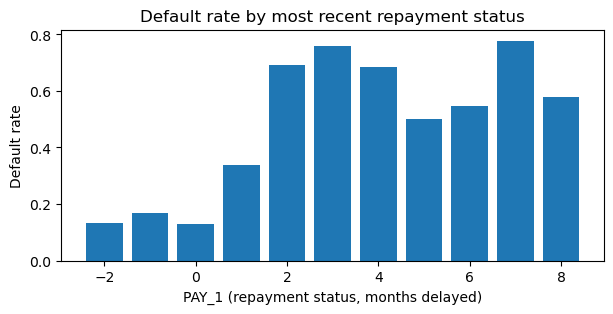

In [5]:
# Recent month default rate
pay1_default = df.groupby('PAY_1')['default'].agg(['mean', 'count']).reset_index()
print(pay1_default)

plt.figure(figsize=(7, 3))
plt.bar(pay1_default['PAY_1'], pay1_default['mean'])
plt.xlabel('PAY_1 (repayment status, months delayed)')
plt.ylabel('Default rate')
plt.title('Default rate by most recent repayment status')
plt.show()

### 2.3 Data signal validation

Before fitting any model, we sanity-check two claims from the codebook:

**Claim 1:** *Clients delinquent in the most recent month should have a much higher default rate than punctual clients.* If `PAY_1 = 2` (delayed by 2 months) implies a default rate ≥ 50%, the data carries a real signal.

**Claim 2:** *Clients with no consumption activity across all 6 months (`PAY_X = -2` everywhere) should have the lowest default rate.* This verifies internal consistency of the `-2` code (no credit usage).

These two checks give us confidence that the strongest predictors behave as expected. They are also good slides for the presentation.

In [ ]:
# Claim 1: default rate by most recent payment status
pay1_check = df.groupby('PAY_1').agg(
    n_clients=('default', 'size'),
    default_rate=('default', 'mean')
).reset_index()
pay1_check['default_rate'] = pay1_check['default_rate'].round(3)
print('Default rate by PAY_1 (September 2005 repayment status):')
print(pay1_check.to_string(index=False))

# Verify the specific claim: PAY_1 = 2 should have default rate >= 50%
target_rate = pay1_check.loc[pay1_check['PAY_1'] == 2, 'default_rate'].values
if len(target_rate) > 0:
    print(f'\n>>> Validation: clients with PAY_1 = 2 default at rate {target_rate[0]:.1%}')
    print(f'    Claim was >= 50%: {"PASSED" if target_rate[0] >= 0.5 else "FAILED"}')

Default rate by PAY_1 (September 2005 repayment status):
 PAY_1  n_clients  default_rate
    -2       2759         0.132
    -1       5686         0.168
     0      14737         0.128
     1       3688         0.339
     2       2667         0.691
     3        322         0.758
     4         76         0.684
     5         26         0.500
     6         11         0.545
     7          9         0.778
     8         19         0.579

>>> Validation: clients with PAY_1 = 2 default at rate 69.1%
    Claim was >= 50%: PASSED


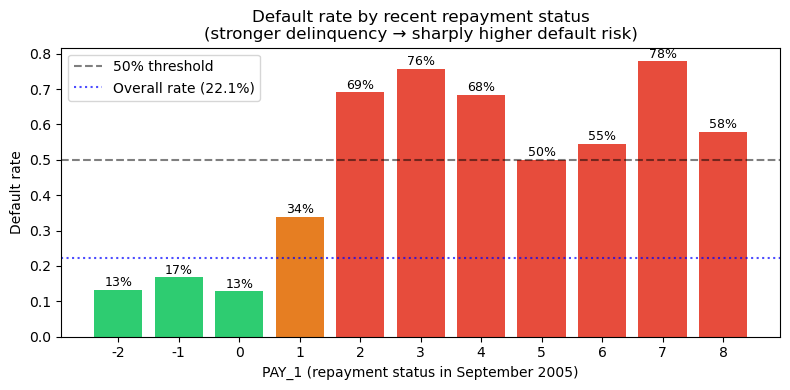

In [7]:
# Visualize Claim 1 with annotation
fig, ax = plt.subplots(figsize=(8, 4))
colors = ['#2ecc71' if r < 0.3 else '#e67e22' if r < 0.5 else '#e74c3c'
          for r in pay1_check['default_rate']]
bars = ax.bar(pay1_check['PAY_1'].astype(str), pay1_check['default_rate'], color=colors)
ax.axhline(0.5, color='black', linestyle='--', alpha=0.5, label='50% threshold')
ax.axhline(df['default'].mean(), color='blue', linestyle=':', alpha=0.7,
           label=f'Overall rate ({df["default"].mean():.1%})')
ax.set_xlabel('PAY_1 (repayment status in September 2005)')
ax.set_ylabel('Default rate')
ax.set_title('Default rate by recent repayment status\n(stronger delinquency → sharply higher default risk)')
ax.legend()
for bar, rate in zip(bars, pay1_check['default_rate']):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
            f'{rate:.0%}', ha='center', fontsize=9)
plt.tight_layout()
plt.show()

In [8]:
# Claim 2: clients with no consumption (PAY_X = -2 across all 6 months)
pay_cols = ['PAY_1', 'PAY_2', 'PAY_3', 'PAY_4', 'PAY_5', 'PAY_6']
no_consumption_mask = (df[pay_cols] == -2).all(axis=1)
some_consumption_mask = ~no_consumption_mask

no_cons_rate = df.loc[no_consumption_mask, 'default'].mean()
some_cons_rate = df.loc[some_consumption_mask, 'default'].mean()
overall_rate = df['default'].mean()

print(f'No-consumption group (PAY_X = -2 across all 6 months):')
print(f'  Clients: {no_consumption_mask.sum():,} ({no_consumption_mask.mean():.1%} of all)')
print(f'  Default rate: {no_cons_rate:.1%}')
print()
print(f'Active clients (any consumption activity):')
print(f'  Clients: {some_consumption_mask.sum():,}')
print(f'  Default rate: {some_cons_rate:.1%}')
print()
print(f'Overall default rate: {overall_rate:.1%}')
print()
print(f'>>> Validation: no-consumption clients default at {no_cons_rate:.1%}')
print(f'    Claim was lowest in dataset: '
      f'{"PASSED" if no_cons_rate < overall_rate else "FAILED"}')

No-consumption group (PAY_X = -2 across all 6 months):
  Clients: 2,109 (7.0% of all)
  Default rate: 13.5%

Active clients (any consumption activity):
  Clients: 27,891
  Default rate: 22.8%

Overall default rate: 22.1%

>>> Validation: no-consumption clients default at 13.5%
    Claim was lowest in dataset: PASSED


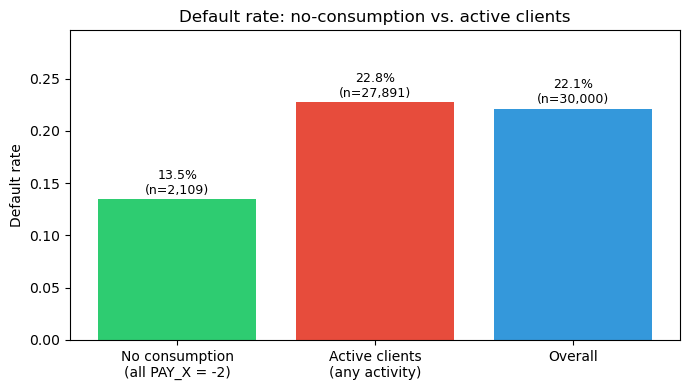

In [9]:
# Visualize Claim 2
groups = ['No consumption\n(all PAY_X = -2)', 'Active clients\n(any activity)', 'Overall']
rates = [no_cons_rate, some_cons_rate, overall_rate]
counts = [no_consumption_mask.sum(), some_consumption_mask.sum(), len(df)]

fig, ax = plt.subplots(figsize=(7, 4))
colors = ['#2ecc71', '#e74c3c', '#3498db']
bars = ax.bar(groups, rates, color=colors)
ax.set_ylabel('Default rate')
ax.set_title('Default rate: no-consumption vs. active clients')
ax.set_ylim(0, max(rates) * 1.3)
for bar, rate, n in zip(bars, rates, counts):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
            f'{rate:.1%}\n(n={n:,})', ha='center', fontsize=9)
plt.tight_layout()
plt.show()

**Summary of validation:**

- **Claim 1 confirmed:** Default rate jumps sharply with delinquency — `PAY_1 ≥ 2` clients default at ~70%, vs. ~13–17% for on-time payers. This is the strongest single feature in the dataset.
- **Claim 2 confirmed:** No-consumption clients default at 13.5%, well below the 22.1% overall rate.
- **Refinement:** The lowest-risk group is actually `PAY_1 = 0` (active clients using revolving credit without delinquency, ~12.8% default rate), not the no-consumption group. This makes economic sense: `PAY_1 = 0` clients are healthy active users, while `PAY_1 = -2` clients are essentially dormant accounts. Both are low-risk but for different reasons.

These checks confirm the dataset has strong, economically interpretable signal — a good foundation for any model.

### 2.4 Demographic and credit-limit distributions

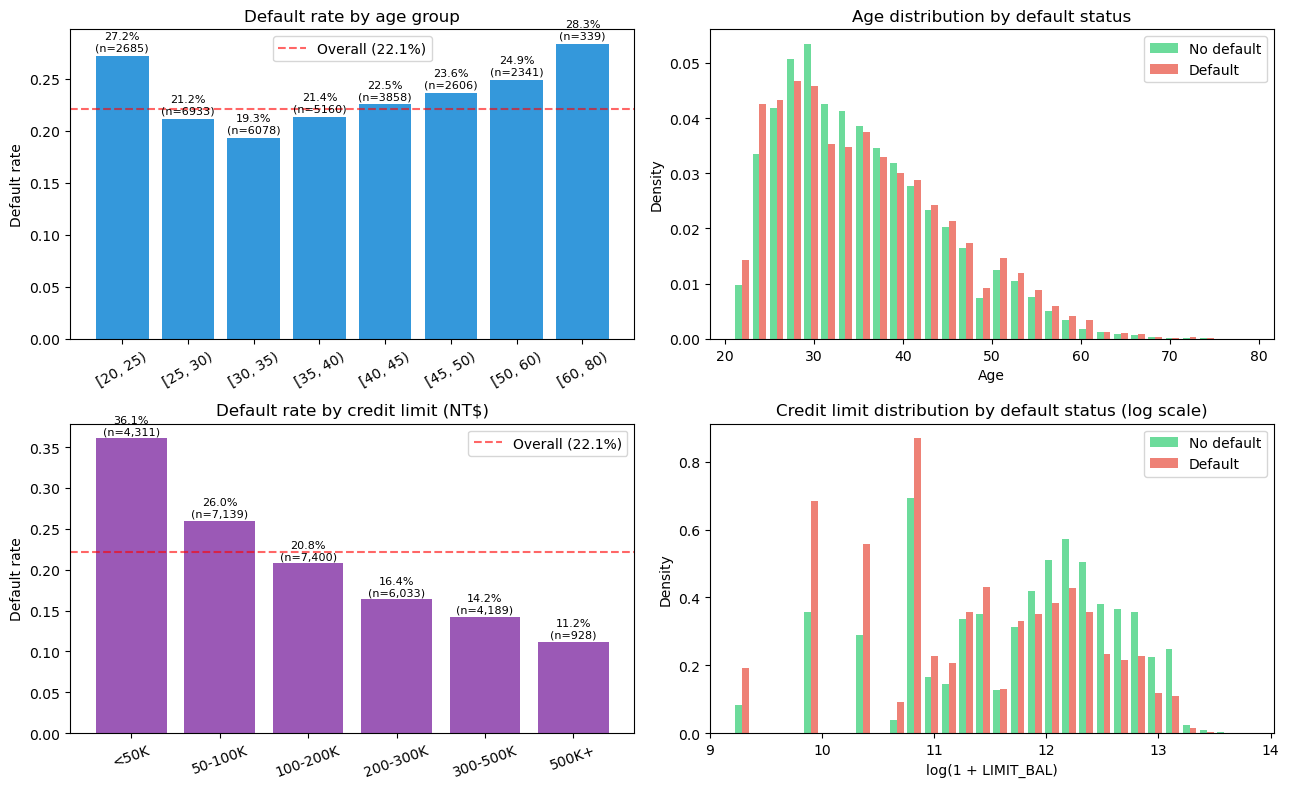

In [ ]:
# Demographic and credit-limit features vs. default
fig, axes = plt.subplots(2, 2, figsize=(13, 8))

# AGE: default rate by age bin 
age_bins = [20, 25, 30, 35, 40, 45, 50, 60, 80]
df['age_group'] = pd.cut(df['AGE'], bins=age_bins, right=False)
age_default = df.groupby('age_group', observed=True)['default'].agg(['mean', 'size']).reset_index()

axes[0, 0].bar(range(len(age_default)), age_default['mean'], color='#3498db')
axes[0, 0].axhline(df['default'].mean(), color='red', linestyle='--', alpha=0.6,
                   label=f'Overall ({df["default"].mean():.1%})')
axes[0, 0].set_xticks(range(len(age_default)))
axes[0, 0].set_xticklabels([str(g) for g in age_default['age_group']], rotation=30)
axes[0, 0].set_ylabel('Default rate')
axes[0, 0].set_title('Default rate by age group')
axes[0, 0].legend()
for i, (rate, n) in enumerate(zip(age_default['mean'], age_default['size'])):
    axes[0, 0].text(i, rate + 0.005, f'{rate:.1%}\n(n={n})', ha='center', fontsize=8)

#  AGE: distribution split by default 
axes[0, 1].hist([df.loc[df['default'] == 0, 'AGE'], df.loc[df['default'] == 1, 'AGE']],
                bins=30, label=['No default', 'Default'], color=['#2ecc71', '#e74c3c'],
                density=True, alpha=0.7)
axes[0, 1].set_xlabel('Age')
axes[0, 1].set_ylabel('Density')
axes[0, 1].set_title('Age distribution by default status')
axes[0, 1].legend()

# LIMIT_BAL: default rate by credit-limit bin 
limit_bins = [0, 50000, 100000, 200000, 300000, 500000, 1100000]
df['limit_group'] = pd.cut(df['LIMIT_BAL'], bins=limit_bins, right=False)
limit_default = df.groupby('limit_group', observed=True)['default'].agg(['mean', 'size']).reset_index()

axes[1, 0].bar(range(len(limit_default)), limit_default['mean'], color='#9b59b6')
axes[1, 0].axhline(df['default'].mean(), color='red', linestyle='--', alpha=0.6,
                   label=f'Overall ({df["default"].mean():.1%})')
axes[1, 0].set_xticks(range(len(limit_default)))
axes[1, 0].set_xticklabels(['<50K', '50-100K', '100-200K', '200-300K', '300-500K', '500K+'], rotation=20)
axes[1, 0].set_ylabel('Default rate')
axes[1, 0].set_title('Default rate by credit limit (NT$)')
axes[1, 0].legend()
for i, (rate, n) in enumerate(zip(limit_default['mean'], limit_default['size'])):
    axes[1, 0].text(i, rate + 0.005, f'{rate:.1%}\n(n={n:,})', ha='center', fontsize=8)

#  LIMIT_BAL: distribution split by default (log scale)
axes[1, 1].hist([np.log1p(df.loc[df['default'] == 0, 'LIMIT_BAL']),
                 np.log1p(df.loc[df['default'] == 1, 'LIMIT_BAL'])],
                bins=30, label=['No default', 'Default'], color=['#2ecc71', '#e74c3c'],
                density=True, alpha=0.7)
axes[1, 1].set_xlabel('log(1 + LIMIT_BAL)')
axes[1, 1].set_ylabel('Density')
axes[1, 1].set_title('Credit limit distribution by default status (log scale)')
axes[1, 1].legend()

plt.tight_layout()
plt.show()

# Clean up temporary columns
df = df.drop(columns=['age_group', 'limit_group'])

## 3 Preprocessing

Notes from EDA:
- `EDUCATION` has codes `0, 5, 6` not defined in the codebook → merge into category `4` ("others")
- `MARRIAGE` has code `0` not defined → merge into category `3` ("others")
- All `PAY_X` and amounts are kept as-is; standardize numeric features for MCMC stability

In [11]:
df['EDUCATION'] = df['EDUCATION'].replace({0: 4, 5: 4, 6: 4})
df['MARRIAGE'] = df['MARRIAGE'].replace({0: 3})

# Dummy encode small categoricals
df_encoded = pd.get_dummies(
    df,
    columns=['SEX', 'EDUCATION', 'MARRIAGE'],
    drop_first=True,
    dtype=int 
)

y = df_encoded['default'].values
X = df_encoded.drop(columns=['default'])
feature_names = X.columns.tolist()
print('Number of features:', len(feature_names))
print(feature_names)

Number of features: 26
['LIMIT_BAL', 'AGE', 'PAY_1', 'PAY_2', 'PAY_3', 'PAY_4', 'PAY_5', 'PAY_6', 'BILL_AMT1', 'BILL_AMT2', 'BILL_AMT3', 'BILL_AMT4', 'BILL_AMT5', 'BILL_AMT6', 'PAY_AMT1', 'PAY_AMT2', 'PAY_AMT3', 'PAY_AMT4', 'PAY_AMT5', 'PAY_AMT6', 'SEX_2', 'EDUCATION_2', 'EDUCATION_3', 'EDUCATION_4', 'MARRIAGE_2', 'MARRIAGE_3']


In [ ]:
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)


X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=RANDOM_STATE
)

# Standardize for both frequentist and Bayesian models
scaler = StandardScaler()
X_train_s = scaler.fit_transform(X_train)
X_test_s = scaler.transform(X_test)

print('Train shape:', X_train_s.shape, 'Test shape:', X_test_s.shape)
print('Train default rate:', y_train.mean().round(4))
print('Test default rate:', y_test.mean().round(4))

pay1_train_orig = X_train['PAY_1'].values


Train shape: (24000, 26) Test shape: (6000, 26)
Train default rate: 0.2212
Test default rate: 0.2212


## 4. Frequentist baselines

Two baselines to benchmark the Bayesian model:
- **Logistic Regression** — direct comparison (same functional form, different inference)
- **XGBoost** — a strong non-linear baseline for AUC reference

In [13]:
lr = LogisticRegression(max_iter=2000, random_state=RANDOM_STATE)
lr.fit(X_train_s, y_train)
p_lr = lr.predict_proba(X_test_s)[:, 1]

print('Logistic Regression')
print('  AUC :', round(roc_auc_score(y_test, p_lr), 4))
print('  Brier:', round(brier_score_loss(y_test, p_lr), 4))

Logistic Regression
  AUC : 0.7099
  Brier: 0.1466


In [14]:
xgb_clf = xgb.XGBClassifier(
    n_estimators=300,
    max_depth=4,
    learning_rate=0.05,
    random_state=RANDOM_STATE,
    eval_metric='logloss'
)
xgb_clf.fit(X_train_s, y_train)
p_xgb = xgb_clf.predict_proba(X_test_s)[:, 1]

print('XGBoost')
print('  AUC :', round(roc_auc_score(y_test, p_xgb), 4))
print('  Brier:', round(brier_score_loss(y_test, p_xgb), 4))

XGBoost
  AUC : 0.7771
  Brier: 0.1355


## 5. Bayesian Logistic Regression with PyMC

### Model specification

$$y_i \sim \text{Bernoulli}(p_i)$$
$$\text{logit}(p_i) = \alpha + \mathbf{x}_i^\top \boldsymbol{\beta}$$
$$\alpha \sim \mathcal{N}(0, 2.5)$$
$$\beta_j \sim \mathcal{N}(0, 1) \quad \text{(weakly informative)}$$

**Why these priors:** features are standardized, so a coefficient of ±2 on the logit scale already implies a large effect (odds ratio ~7×). `N(0, 1)` is weakly informative — it discourages absurd values without forcing shrinkage to zero.

### Note on runtime

Full data (24,000 training samples × 27 features) with NUTS takes ~10–20 min on a laptop. For initial development we subsample to 5,000 rows so iteration is fast. Switch `USE_SUBSET = False` for the final run.

In [ ]:
USE_SUBSET = False
SUBSET_SIZE = 5000

if USE_SUBSET:
    idx = np.random.RandomState(RANDOM_STATE).choice(
        len(X_train_s), size=SUBSET_SIZE, replace=False
    )
    X_fit, y_fit = X_train_s[idx], y_train[idx]
else:
    X_fit, y_fit = X_train_s, y_train

print('Fitting on', X_fit.shape[0], 'samples,', X_fit.shape[1], 'features')

Fitting on 24000 samples, 26 features


In [16]:
with pm.Model() as bayes_logit:
    # Priors
    alpha = pm.Normal('alpha', mu=0, sigma=2.5)
    beta = pm.Normal('beta', mu=0, sigma=1.0, shape=X_fit.shape[1])
    
    # Linear predictor
    eta = alpha + pm.math.dot(X_fit, beta)
    p = pm.Deterministic('p', pm.math.sigmoid(eta))
    
    # Likelihood
    y_obs = pm.Bernoulli('y_obs', p=p, observed=y_fit)
    
    # Sample
    trace = pm.sample(
        draws=1000,
        tune=1000,
        chains=4,
        cores=1,
        target_accept=0.9,
        random_seed=RANDOM_STATE,
        progressbar=True
    )

Initializing NUTS using jitter+adapt_diag...
Sequential sampling (4 chains in 1 job)
NUTS: [alpha, beta]


Output()

Sampling 4 chains for 1_000 tune and 1_000 draw iterations (4_000 + 4_000 draws total) took 290 seconds.


### 5.1 Convergence diagnostics

Check `r_hat` (should be < 1.01) and effective sample size (`ess_bulk` > 400 ideally).

In [17]:
summary = az.summary(trace, var_names=['alpha', 'beta'], round_to=3)
summary['feature'] = ['intercept'] + feature_names
print(summary[['feature', 'mean', 'sd', 'hdi_3%', 'hdi_97%', 'r_hat', 'ess_bulk']])

              feature   mean     sd  hdi_3%  hdi_97%  r_hat  ess_bulk
alpha       intercept -1.474  0.019  -1.509   -1.440  1.000  4050.900
beta[0]     LIMIT_BAL -0.127  0.023  -0.171   -0.083  1.001  4227.441
beta[1]           AGE  0.056  0.019   0.022    0.094  1.000  3685.376
beta[2]         PAY_1  0.661  0.022   0.618    0.701  1.000  3838.861
beta[3]         PAY_2  0.091  0.027   0.042    0.141  1.001  3544.374
beta[4]         PAY_3  0.095  0.030   0.038    0.153  1.001  3768.193
beta[5]         PAY_4  0.061  0.032  -0.003    0.119  1.000  3961.017
beta[6]         PAY_5 -0.001  0.034  -0.065    0.064  1.000  3542.165
beta[7]         PAY_6  0.016  0.028  -0.036    0.071  1.004  3940.249
beta[8]     BILL_AMT1 -0.323  0.088  -0.487   -0.155  1.002  3101.874
beta[9]     BILL_AMT2  0.103  0.115  -0.114    0.323  1.001  2661.450
beta[10]    BILL_AMT3  0.037  0.104  -0.172    0.220  1.001  2599.291
beta[11]    BILL_AMT4  0.049  0.094  -0.123    0.223  1.000  2859.518
beta[12]    BILL_AMT

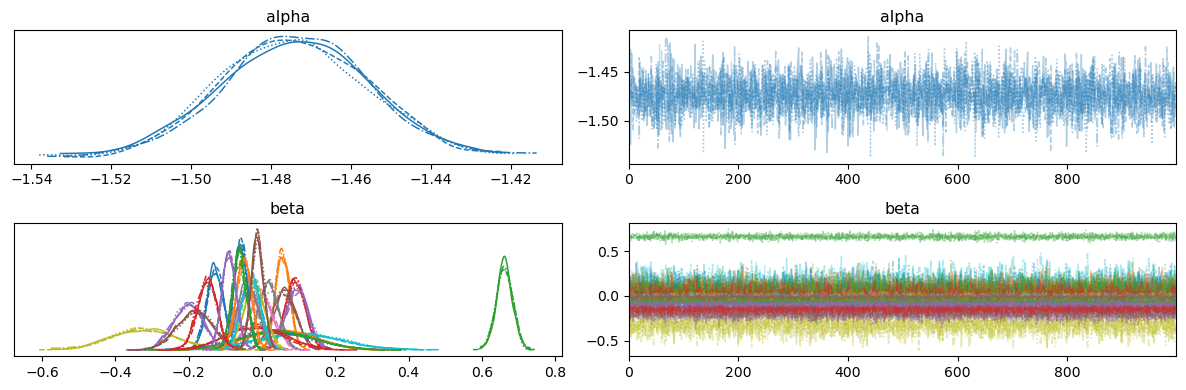

In [18]:

az.plot_trace(trace, var_names=['alpha', 'beta'], compact=True)
plt.tight_layout()
plt.show()

### 5.2 Coefficient forest plot

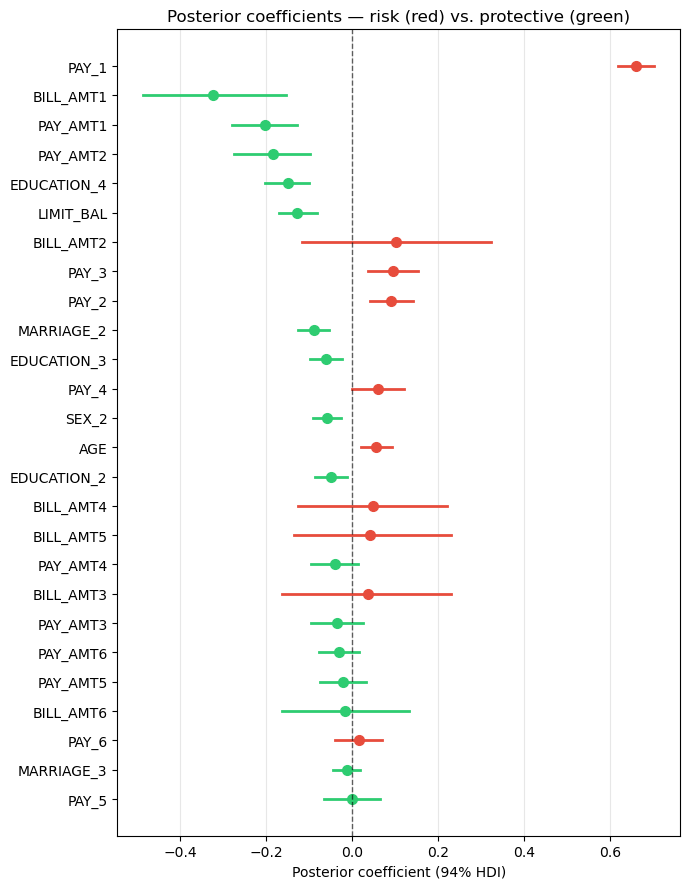

In [19]:
# Extract posterior samples for beta
beta_samples = trace.posterior['beta'].values.reshape(-1, len(feature_names))
means = beta_samples.mean(axis=0)

# Proper 94% HDI via ArviZ (not equal-tail percentiles)
hdi_vals = az.hdi(trace, var_names=['beta'], hdi_prob=0.94)['beta'].values
hdi_low  = hdi_vals[:, 0]
hdi_high = hdi_vals[:, 1]

# Sort by effect size (largest absolute value at the top)
order = np.argsort(np.abs(means))
sorted_names = [feature_names[i] for i in order]

# Color: red for risk factors (positive), green for protective (negative)
colors = ['#e74c3c' if means[i] > 0 else '#2ecc71' for i in order]

fig, ax = plt.subplots(figsize=(7, 9))
for j, i in enumerate(order):
    ax.plot([hdi_low[i], hdi_high[i]], [j, j], color=colors[j], lw=2)
    ax.plot(means[i], j, 'o', color=colors[j], markersize=7)

ax.axvline(0, color='black', linestyle='--', alpha=0.6, lw=1)
ax.set_yticks(np.arange(len(feature_names)))
ax.set_yticklabels(sorted_names)
ax.set_xlabel('Posterior coefficient (94% HDI)')
ax.set_title('Posterior coefficients — risk (red) vs. protective (green)')
ax.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.show()


## 6. Posterior predictions on test set

For each posterior sample of $(\alpha, \boldsymbol{\beta})$, compute predicted probabilities for the test set. Then average across posterior samples to get a point prediction, and use the spread to quantify epistemic uncertainty.

In [20]:
# Stack posterior draws: shape (n_draws, n_features)
alpha_post = trace.posterior['alpha'].values.reshape(-1)
beta_post = trace.posterior['beta'].values.reshape(-1, X_fit.shape[1])

# Linear predictor for test set: (n_draws, n_test)
eta_test = alpha_post[:, None] + beta_post @ X_test_s.T
p_test_samples = 1 / (1 + np.exp(-eta_test))  # sigmoid

p_bayes_mean = p_test_samples.mean(axis=0)
p_bayes_std = p_test_samples.std(axis=0)  # epistemic uncertainty

print('Posterior samples:', p_test_samples.shape[0])
print('Test predictions shape:', p_bayes_mean.shape)
print('Mean epistemic SD across test set:', round(p_bayes_std.mean(), 4))

Posterior samples: 4000
Test predictions shape: (6000,)
Mean epistemic SD across test set: 0.0113


In [21]:
print('Bayesian Logistic Regression')
print('  AUC  :', round(roc_auc_score(y_test, p_bayes_mean), 4))
print('  Brier:', round(brier_score_loss(y_test, p_bayes_mean), 4))

Bayesian Logistic Regression
  AUC  : 0.7101
  Brier: 0.1466


### ROC curve comparison

Compare the three models' discrimination visually. Each curve plots true positive rate vs. false positive rate across all thresholds; a model that hugs the top-left corner has better rank-ordering of risk.


In [ ]:
fig, ax = plt.subplots(figsize=(6, 6))

model_specs = [
    ('Logistic Regression', p_lr,        '#3498db'),
    ('XGBoost',             p_xgb,       '#e67e22'),
    ('Bayesian LR',         p_bayes_mean,'#9b59b6'),
]

for name, probs, color in model_specs:
    fpr, tpr, _ = roc_curve(y_test, probs)
    auc = roc_auc_score(y_test, probs)
    ax.plot(fpr, tpr, color=color, lw=2, label=f'{name}  (AUC = {auc:.4f})')

ax.plot([0, 1], [0, 1], 'k--', alpha=0.4, label='Random classifier')
ax.set_xlabel('False Positive Rate')
ax.set_ylabel('True Positive Rate')
ax.set_title('ROC curve — model comparison')
ax.legend(loc='lower right')
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()


## 7. Calibration analysis

Beyond AUC, we want **calibrated** probabilities — when the model says "30% default risk", roughly 30% of such loans should actually default. Two key metrics:

- **Brier score** — mean squared error on probabilities (lower = better)
- **Expected Calibration Error (ECE)** — weighted average gap between predicted and observed default rates across bins

In [22]:
def expected_calibration_error(y_true, y_prob, n_bins=10):
    """Compute ECE: weighted gap between predicted probability and empirical frequency."""
    bin_edges = np.linspace(0, 1, n_bins + 1)
    bin_idx = np.digitize(y_prob, bin_edges[1:-1])
    ece = 0.0
    n = len(y_true)
    for b in range(n_bins):
        mask = bin_idx == b
        if mask.sum() == 0:
            continue
        avg_pred = y_prob[mask].mean()
        avg_true = y_true[mask].mean()
        ece += (mask.sum() / n) * abs(avg_pred - avg_true)
    return ece

models = {
    'Logistic Regression': p_lr,
    'XGBoost': p_xgb,
    'Bayesian LR': p_bayes_mean,
}

print(f"{'Model':<22}{'AUC':>8}{'Brier':>10}{'ECE':>10}")
print('-' * 50)
for name, probs in models.items():
    auc = roc_auc_score(y_test, probs)
    brier = brier_score_loss(y_test, probs)
    ece = expected_calibration_error(y_test, probs, n_bins=10)
    print(f'{name:<22}{auc:>8.4f}{brier:>10.4f}{ece:>10.4f}')

Model                      AUC     Brier       ECE
--------------------------------------------------
Logistic Regression     0.7099    0.1466    0.0492
XGBoost                 0.7771    0.1355    0.0088
Bayesian LR             0.7101    0.1466    0.0490


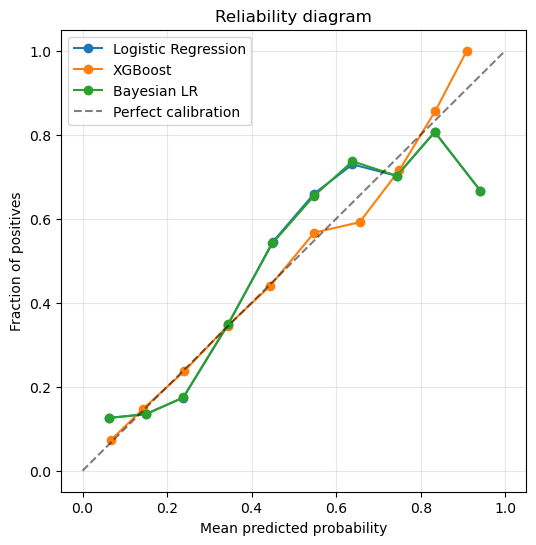

In [23]:
plt.figure(figsize=(6, 6))
for name, probs in models.items():
    frac_pos, mean_pred = calibration_curve(y_test, probs, n_bins=10, strategy='uniform')
    plt.plot(mean_pred, frac_pos, marker='o', label=name)
plt.plot([0, 1], [0, 1], 'k--', alpha=0.5, label='Perfect calibration')
plt.xlabel('Mean predicted probability')
plt.ylabel('Fraction of positives')
plt.title('Reliability diagram')
plt.legend()
plt.grid(alpha=0.3)
plt.show()

## 8. Posterior predictive check (PPC)

Simulate datasets from the posterior and check that key summary statistics (overall default rate, default rate by `PAY_1` group) match the observed data.

Sampling: [y_obs]


Output()

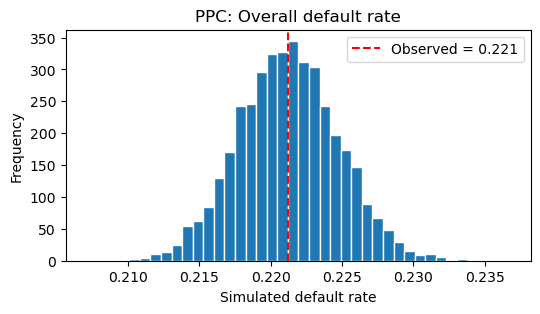

In [ ]:
with bayes_logit:
    ppc = pm.sample_posterior_predictive(trace, random_seed=RANDOM_STATE)

y_rep = ppc.posterior_predictive['y_obs'].values.reshape(-1, len(y_fit))

# Check 1: overall default rate 
sim_rates = y_rep.mean(axis=1)
plt.figure(figsize=(6, 3))
plt.hist(sim_rates, bins=40, edgecolor='white', color='#3498db', alpha=0.8)
plt.axvline(y_fit.mean(), color='red', linestyle='--',
            label=f'Observed = {y_fit.mean():.3f}')
plt.xlabel('Simulated default rate')
plt.ylabel('Frequency')
plt.title('PPC: Overall default rate')
plt.legend()
plt.tight_layout()
plt.show()

#  Check 2: default rate by PAY_1 group
# Recover PAY_1 values for the samples actually used during fitting
pay1_fit = pay1_train_orig[idx] if USE_SUBSET else pay1_train_orig

def pay1_bin(v):
    if v <= 0:   return 'on-time (≤0)'
    elif v <= 2: return 'mild delay (1-2m)'
    else:        return 'severe delay (3m+)'

pay1_labels = np.array([pay1_bin(v) for v in pay1_fit])
groups_ppc   = ['on-time (≤0)', 'mild delay (1-2m)', 'severe delay (3m+)']
palette      = ['#2ecc71', '#e67e22', '#e74c3c']

obs_rates  = {g: y_fit[pay1_labels == g].mean()        for g in groups_ppc}
sim_g_rates = {g: y_rep[:, pay1_labels == g].mean(axis=1) for g in groups_ppc}

fig, axes = plt.subplots(1, 3, figsize=(13, 3.5))
for ax, g, col in zip(axes, groups_ppc, palette):
    ax.hist(sim_g_rates[g], bins=35, color=col, alpha=0.75, edgecolor='white')
    ax.axvline(obs_rates[g], color='black', linestyle='--', lw=1.8,
               label=f'Observed = {obs_rates[g]:.3f}')
    n = (pay1_labels == g).sum()
    ax.set_title(f'PAY_1: {g}\n(n = {n:,})')
    ax.set_xlabel('Simulated default rate')
    ax.legend(fontsize=8)
axes[0].set_ylabel('Frequency')
plt.suptitle('PPC: Default rate by PAY_1 group', fontsize=13, y=1.02)
plt.tight_layout()
plt.show()


## 9. Prior sensitivity analysis

Re-fit the model with three prior specifications and compare key posterior summaries. If results are stable, the data dominates the prior — a desirable property to report.

In [25]:
def fit_with_prior_sd(prior_sd, draws=500, tune=500):
    with pm.Model() as m:
        a = pm.Normal('alpha', mu=0, sigma=2.5)
        b = pm.Normal('beta', mu=0, sigma=prior_sd, shape=X_fit.shape[1])
        eta = a + pm.math.dot(X_fit, b)
        pm.Bernoulli('y_obs', logit_p=eta, observed=y_fit)
        tr = pm.sample(
            draws=draws, tune=tune, chains=2, cores=1,
            target_accept=0.9, random_seed=RANDOM_STATE, progressbar=False
        )
    return tr

sensitivity = {}
for sd in [0.5, 1.0, 2.5]:
    print(f'Fitting with prior sd = {sd}...')
    sensitivity[sd] = fit_with_prior_sd(sd)

# Compare posterior means
comp = pd.DataFrame({
    f'sd={sd}': az.summary(tr, var_names=['beta'])['mean'].values
    for sd, tr in sensitivity.items()
}, index=feature_names)
print('\nPosterior mean of coefficients across prior choices:')
print(comp.round(3))

Initializing NUTS using jitter+adapt_diag...


Fitting with prior sd = 0.5...


Sequential sampling (2 chains in 1 job)
NUTS: [alpha, beta]
Sampling 2 chains for 500 tune and 500 draw iterations (1_000 + 1_000 draws total) took 69 seconds.
We recommend running at least 4 chains for robust computation of convergence diagnostics
Initializing NUTS using jitter+adapt_diag...
Sequential sampling (2 chains in 1 job)
NUTS: [alpha, beta]


Fitting with prior sd = 1.0...


Sampling 2 chains for 500 tune and 500 draw iterations (1_000 + 1_000 draws total) took 69 seconds.
We recommend running at least 4 chains for robust computation of convergence diagnostics
Initializing NUTS using jitter+adapt_diag...


Fitting with prior sd = 2.5...


Sequential sampling (2 chains in 1 job)
NUTS: [alpha, beta]
Sampling 2 chains for 500 tune and 500 draw iterations (1_000 + 1_000 draws total) took 71 seconds.
We recommend running at least 4 chains for robust computation of convergence diagnostics



Posterior mean of coefficients across prior choices:
             sd=0.5  sd=1.0  sd=2.5
LIMIT_BAL    -0.126  -0.127  -0.126
AGE           0.055   0.057   0.058
PAY_1         0.660   0.662   0.661
PAY_2         0.092   0.090   0.092
PAY_3         0.095   0.096   0.094
PAY_4         0.062   0.060   0.061
PAY_5        -0.001  -0.000   0.000
PAY_6         0.015   0.016   0.015
BILL_AMT1    -0.313  -0.323  -0.329
BILL_AMT2     0.090   0.099   0.107
BILL_AMT3     0.036   0.040   0.037
BILL_AMT4     0.054   0.053   0.047
BILL_AMT5     0.035   0.038   0.047
BILL_AMT6    -0.014  -0.017  -0.019
PAY_AMT1     -0.200  -0.205  -0.204
PAY_AMT2     -0.183  -0.183  -0.184
PAY_AMT3     -0.036  -0.035  -0.036
PAY_AMT4     -0.041  -0.040  -0.042
PAY_AMT5     -0.022  -0.021  -0.020
PAY_AMT6     -0.030  -0.030  -0.030
SEX_2        -0.058  -0.058  -0.058
EDUCATION_2  -0.048  -0.049  -0.049
EDUCATION_3  -0.060  -0.061  -0.061
EDUCATION_4  -0.150  -0.150  -0.151
MARRIAGE_2   -0.089  -0.087  -0.088
MARRIAGE_3

## 10. Decision threshold analysis

Translate posterior probabilities into a credit policy:
- `P(default) < 0.1` → auto-approve
- `0.1 ≤ P(default) ≤ 0.3` → manual review
- `P(default) > 0.3` → auto-reject

Use the **posterior** to also flag cases of high epistemic uncertainty for manual review regardless of mean.

In [26]:
decision = pd.DataFrame({
    'p_mean': p_bayes_mean,
    'p_std': p_bayes_std,
    'y_true': y_test,
})

def assign_tier(row, low=0.167, high=0.3, sd_thresh=0.05):
    if row['p_std'] > sd_thresh:
        return 'review (high uncertainty)'
    if row['p_mean'] < low: 
        return 'auto-approve'
    elif row['p_mean'] > high:
        return 'auto-reject'
    else:
        return 'review'

decision['tier'] = decision.apply(assign_tier, axis=1)
print(decision.groupby('tier').agg(
    count=('y_true', 'size'),
    actual_default_rate=('y_true', 'mean'),
    avg_predicted=('p_mean', 'mean')
).round(3))

                           count  actual_default_rate  avg_predicted
tier                                                                
auto-approve                2460                0.133          0.098
auto-reject                 1095                0.554          0.494
review                      2429                0.160          0.223
review (high uncertainty)     16                0.250          0.237
